In [1]:
import gc
import os
import time
import statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from memory_profiler import memory_usage
from agtools.assemblers import megahit

# Profiling code

In [2]:
# GFA Line Count
def grep_count(line_prefix, file_path):
    if not os.path.exists(file_path):
        return 0
    with open(file_path, 'r') as f:
        return sum(1 for line in f if line.startswith(line_prefix))

# Get file size in MB
def get_file_size(path):
    if os.path.exists(path):
        return os.path.getsize(path) / (1024 * 1024)  # Convert to MB
    return 0.0

In [3]:
def profile_get_contig_graph(graph_file, contigs_file):
    start = time.perf_counter()
    
    mem_trace, _ = memory_usage(
        (megahit.get_contig_graph, (graph_file, contigs_file)),
        retval=True,
        interval=0.01,
        timeout=None
    )
    
    end = time.perf_counter()
    
    elapsed = end - start
    peak_mem = max(mem_trace) - min(mem_trace)
    
    return elapsed, peak_mem

def profile_folder(folder_path, runs=10):
    graph_file = os.path.join(folder_path, "converted_graph.gfa")
    contigs_file = os.path.join(folder_path, "final.contigs.fa")

    times = []
    peak_mems = []

    for _ in range(runs):
        elapsed, peak = profile_get_contig_graph(graph_file, contigs_file)
        times.append(elapsed)
        peak_mems.append(peak)

    # GFA line stats
    count_S = grep_count("S", graph_file)
    count_L = grep_count("L", graph_file)
    count_P = grep_count("P", graph_file)

    # File sizes in MB
    size_graph = get_file_size(graph_file)
    size_fasta = get_file_size(contigs_file)

    return {
        "folder": os.path.basename(folder_path),
        "time_min": min(times),
        "time_max": max(times),
        "time_mean": statistics.mean(times),
        "time_std": statistics.stdev(times),
        "peak_mem_min": min(peak_mems),
        "peak_mem_max": max(peak_mems),
        "peak_mem_mean": statistics.mean(peak_mems),
        "peak_mem_std": statistics.stdev(peak_mems),
        "gfa_S": count_S,
        "gfa_L": count_L,
        "gfa_P": count_P,
        "size_graph_MB": size_graph,
        "size_fasta_MB": size_fasta,
    }

def batch_profile(folders, runs=10):
    results = []
    
    for folder in folders:
        
        print(f"Profiling: {folder}")
        
        stats = profile_folder(folder, runs)
        results.append(stats)
        
        # Manually trigger garbage collection
        gc.collect()
        
    return pd.DataFrame(results)

# Profile SPAdes data

In [4]:
folders = [
    "data/MEGAHIT/ERR2752143",
    "data/MEGAHIT/ERR2752144",
    "data/MEGAHIT/ERR2752145",
    "data/MEGAHIT/ERR2752146",
    "data/MEGAHIT/ERR2752147",
]

# Run profiling
df_results = batch_profile(folders, runs=10)

Profiling: data/MEGAHIT/ERR2752143
Profiling: data/MEGAHIT/ERR2752144
Profiling: data/MEGAHIT/ERR2752145
Profiling: data/MEGAHIT/ERR2752146
Profiling: data/MEGAHIT/ERR2752147


In [5]:
# Show results
df_results

,folder,time_min,time_max,time_mean,time_std,peak_mem_min,peak_mem_max,peak_mem_mean,peak_mem_std,gfa_S,gfa_L,gfa_P,size_graph_MB,size_fasta_MB
0,ERR2752143,17.633339,18.300206,17.972409,0.233681,415.921875,958.015625,483.604688,167.335111,748451,434894,0,624.759020,579.695361
1,ERR2752144,22.541879,23.411661,22.866050,0.293714,538.750000,600.031250,558.854687,22.252975,946706,579536,0,805.834826,745.711737
2,ERR2752145,29.929480,30.561124,30.078632,0.182545,681.656250,743.156250,691.553125,18.316950,1265386,628316,0,1044.944984,978.169227
3,ERR2752146,39.855552,41.092945,40.126159,0.362426,1037.906250,1590.593750,1131.620312,161.989628,1666049,1014168,0,1352.482845,1245.663961
4,ERR2752147,50.105950,50.492650,50.305154,0.104300,1282.359375,1415.625000,1326.115625,39.129489,2095749,1217564,0,1633.681917,1504.283463


In [6]:
# Save to CSV
df_results.to_csv("data/profiling_megahit.csv", index=False)

# Plot

In [7]:
# Read the profiling results from CSV file
df_results = pd.read_csv("data/profiling_megahit.csv")

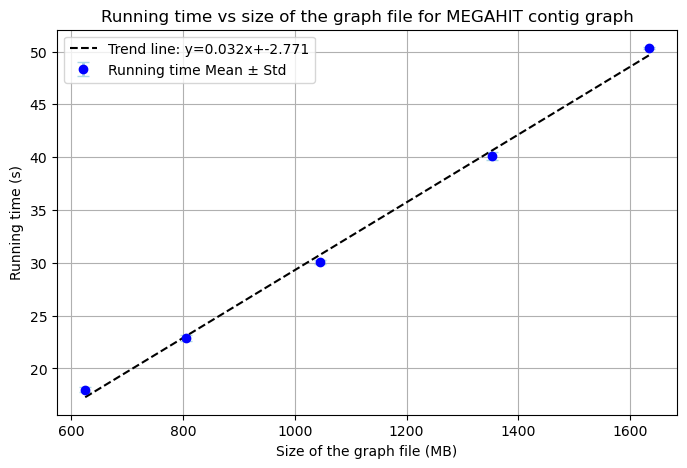

In [8]:
x = df_results["size_graph_MB"]
y = df_results["time_mean"]
yerr = df_results["time_std"]

# Fit a simple linear regression for the trend line
m, b = np.polyfit(x, y, 1)  # slope, intercept
trend_y = m * x + b

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=yerr, fmt='o', color='blue',
             ecolor='lightblue', elinewidth=2, capsize=4,
             label='Running time Mean ± Std')

# Plot trend line
plt.plot(x, trend_y, '--', color='black', label=f'Trend line: y={m:.3f}x+{b:.3f}')

plt.xlabel("Size of the graph file (MB)")
plt.ylabel("Running time (s)")
plt.title("Running time vs size of the graph file for MEGAHIT contig graph")
plt.legend()
plt.grid(True)

# Save to file
plt.savefig("megahit_time.png", dpi=300, bbox_inches='tight')
plt.show()

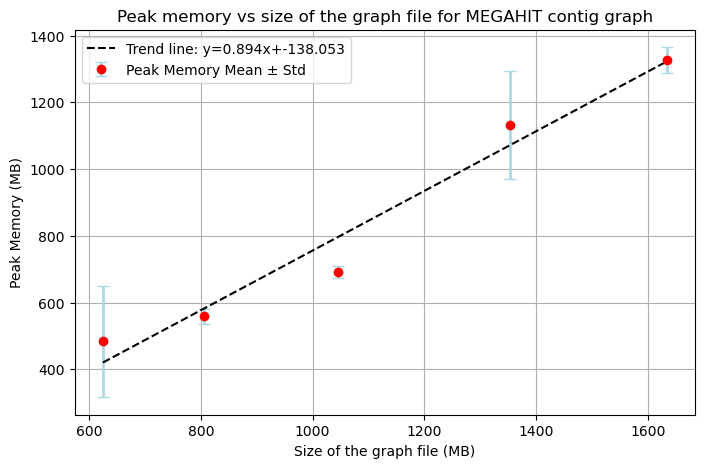

In [9]:
# Plot Peak Memory Mean with error bars
x = df_results["size_graph_MB"]
y = df_results["peak_mem_mean"]
yerr = df_results["peak_mem_std"]

# Fit a simple linear regression for the trend line
m, b = np.polyfit(x, y, 1)  # slope, intercept
trend_y = m * x + b

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, yerr=yerr, fmt='o', color='red',
             ecolor='lightblue', elinewidth=2, capsize=4,
             label='Peak Memory Mean ± Std')

# Plot trend line
plt.plot(x, trend_y, '--', color='black', label=f'Trend line: y={m:.3f}x+{b:.3f}')

plt.xlabel("Size of the graph file (MB)")
plt.ylabel("Peak Memory (MB)")
plt.title("Peak memory vs size of the graph file for MEGAHIT contig graph")
plt.legend()
plt.grid(True)

# Save to file
plt.savefig("megahit_mem.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# %%time
# %%memit

# cg = spades.get_contig_graph(
#     f"{folder_path}/assembly_graph_with_scaffolds.gfa", 
#     f"{folder_path}/contigs.fasta", 
#     f"{folder_path}/contigs.paths"
# )